In [1]:
import numpy as np
import gensim.downloader as api
import matplotlib.pyplot as plt


# Centered Kernel Alignment Sandbox 

This is a sandbox for testing how CKA could be used as a heuristic to measure reusability and therefore compositionality ...

In [2]:
def linear_kernel(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Compute the linear kernel between two sets of vectors. (Gram matrix)

    Args:
        x (np.ndarray): An (n_samples_x, n_features) array.
        y (np.ndarray): An (n_samples_y, n_features) array.
    Returns:
        np.ndarray: An (n_samples_x, n_samples_y) kernel matrix.
    """
    return x @ y.T

def centering_matrix(n: int) -> np.ndarray:
    """
    Create a centering matrix of size n x n.

    Args:
        n (int): The size of the centering matrix.
    Returns:
        np.ndarray: The centering matrix.
    """
    I = np.eye(n)
    ones = np.ones((n, n)) / n
    return I - ones

def HSIC(K: np.ndarray, L: np.ndarray) -> float:
    """
    Compute the Hilbert-Schmidt Independence Criterion (HSIC) between two kernel matrices.

    Args:
        K (np.ndarray): An (n_samples, n_samples) kernel matrix.
        L (np.ndarray): An (n_samples, n_samples) kernel matrix.
    Returns:
        float: The HSIC value.
    """
    n = K.shape[0]
    H = centering_matrix(n)
    K_centered = H @ K @ H
    L_centered = H @ L @ H
    hsic_value = np.trace(K_centered @ L_centered) / (n - 1)**2
    return hsic_value

def CKA(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Compute the Centered Kernel Alignment (CKA) between two datasets.

    Args:
        X (np.ndarray): An (n_samples, n_features_x) array.
        Y (np.ndarray): An (n_samples, n_features_y) array.
    Returns:
        float: The CKA value.
    """
    K = linear_kernel(X, X)
    L = linear_kernel(Y, Y)
    hsic_xy = HSIC(K, L)
    hsic_xx = HSIC(K, K)
    hsic_yy = HSIC(L, L)
    cka_value = hsic_xy / np.sqrt(hsic_xx * hsic_yy)
    return cka_value

## Testing

In [3]:
def _get_one():
    X = np.cos(.1 * np.pi * np.arange(10)).reshape((-1, 1))
    Y = np.cos(2 + .07 * np.pi * np.arange(10)).reshape((-1, 1))
    return X, Y

def _get_multi():
    X = (np.cos(.1 * np.pi * np.arange(10).reshape((-1, 1)) *
         np.linspace(.5, 1.5, num=3).reshape((1, -1))))
    Y = (np.cos(.5 + .07 * np.pi * np.arange(10).reshape((-1, 1)) *
         np.linspace(.7, 1.3, num=4).reshape((1, -1))))
    return X, Y

def test_identity_lenient():
    """Create a random matrix, check it is perfectly correlated with itself."""
    X, _ = _get_multi()
    np.testing.assert_allclose(CKA(X, X), 1.0)

def test_column_swaps():
    """A matrix is perfectly correlated with itself even with column swaps."""
    X, _ = _get_multi()
    c = CKA(X[:, [0, 1]], X[:, [1, 0]])
    np.testing.assert_allclose(c, 1.0)

def test_centering():
    """A matrix is perfectly correlated with itself with column offsets."""
    X, _ = _get_multi()
    Xp = X.copy()
    Xp[:, 1] += 1.0

    c = CKA(X, Xp)
    np.testing.assert_allclose(c, 1.0)

def test_pure():
    """Check that a function doesn't change the original matrices."""
    X, _ = _get_multi()
    Xp = X.copy()
    Xp[:, 1] += 1.0

    Xp_original = Xp.copy()
    c = CKA(X, Xp)
    np.testing.assert_allclose(Xp_original[:, 1], Xp[:, 1])

def test_corr():
    """The CKA of two vectors is the square of the correlation coefficient"""
    X, Y = _get_one()
    c1 = CKA(X, Y)
    c2 = np.corrcoef(X.squeeze(), Y.squeeze())[0, 1] ** 2
    np.testing.assert_allclose(c1, c2)

def test_isoscaling():
    """CKA is insensitive to scaling by a scalar"""
    X, Y = _get_multi()
    c1 = CKA(X, Y)
    c2 = CKA(2.0 * X, - 1 * Y)
    np.testing.assert_allclose(c1, c2)

def test_rotation():
    """CKA is insensitive to rotations"""
    X, Y = _get_multi()
    X0 = X[:, :2]
    X0p = X0 @ np.array([[1, -1], [1, 1]]) / np.sqrt(2)
    c1 = CKA(X0, Y)
    c2 = CKA(X0p, Y)
    np.testing.assert_allclose(c1, c2)

def test_no_iso():
    """CKA is sensitive to column scaling"""
    X, Y = _get_multi()
    X0 = X[:, :2]
    X0p = X0 @ np.array([[1, 1], [10, 1]])
    c1 = CKA(X0, Y)
    c2 = CKA(X0p, Y)
    assert abs(c1 - c2) > .001

test_pure()
test_corr()
test_isoscaling()
test_rotation()
test_no_iso()
print("All tests passed.")

All tests passed.


### Example 1: Animals

Great now we think the model works as expected - lets have a look at our first 'easy example'

We have two cases:

Case 1: Bad composition 
    z1 = {kitten, tabby, calf, beagle, foal, shire, lamb}
    z2 = z1 | noise

Case 2: Good composition
    z1 = {young, old}
    z2 = {cat, cow, dog, horse, sheep}

trainset (in case 1 terms) = [kitten, tabby, calf, beagle, foal, shire, lamb] * n + noise?
testset (in case 1 terms) = [cow, sheep] * n + noise?

We then calculate the CKA of each overall and per latent variable and assess.

In [4]:
model = api.load("word2vec-google-news-300")  # 300-d vectors

In [5]:
print(model['dog'].min(), model['cat'].max())

-0.45898438 0.4921875


CKA z1 (bad composition): 0.6394116171427955
CKA z2 (bad composition): 0.958005907764801
CKA (bad composition): 0.5937970276738099


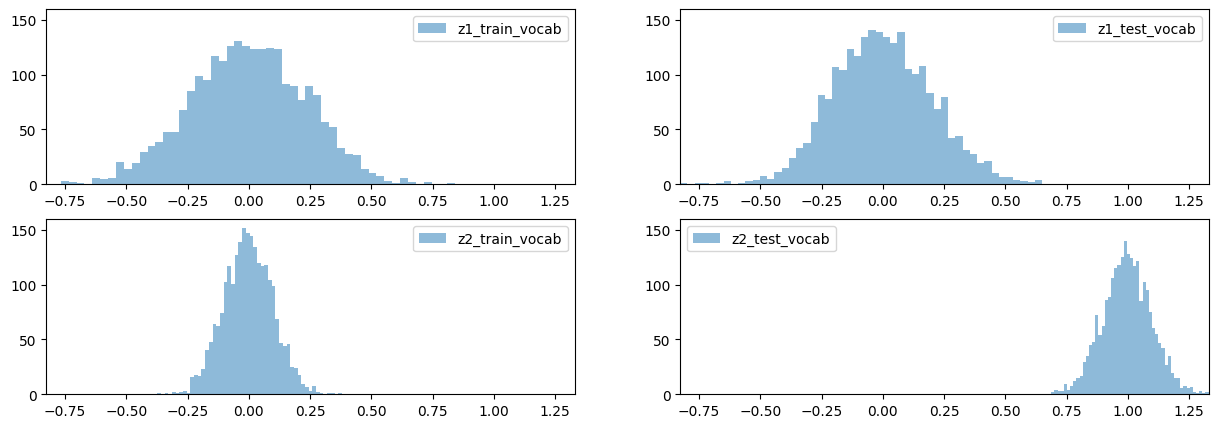

In [6]:
# Case 1: Bad composition
np.random.seed(0)
z1_train_vocab = model[['kitten', 'tabby', 'calf', 'beagle', 'puppy', 'foal', 'shire', 'lamb']] + np.random.randn(8, 300) * 0.1
z2_train_vocab = np.zeros((8, 300)) + np.random.randn(8, 300) * 0.1 #np.random.randn(8, 300) 

z1_test_vocab = model[np.repeat(['cow', 'sheep'], 4)] + np.random.randn(8, 300) * 0.1
z2_test_vocab = np.ones((8, 300)) + np.random.randn(8, 300) * 0.1 #np.random.randn(8, 300) 

cka_bad_z1 = CKA(z1_train_vocab, z1_test_vocab)
print(f"CKA z1 (bad composition): {cka_bad_z1}")

cka_bad_z2 = CKA(z2_train_vocab, z2_test_vocab)
print(f"CKA z2 (bad composition): {cka_bad_z2}")

z_train = np.concatenate([z1_train_vocab, z2_train_vocab], axis=0)
z_test = np.concatenate([z1_test_vocab, z2_test_vocab], axis=0)

cka_bad = CKA(z_train, z_test)
print(f"CKA (bad composition): {cka_bad}")

fig, axis = plt.subplots(2, 2, figsize=(15, 5))
axis[0, 0].hist(z1_train_vocab.flatten(), bins=50, alpha=0.5, label='z1_train_vocab')
axis[0, 1].hist(z1_test_vocab.flatten(), bins=50, alpha=0.5, label='z1_test_vocab')
axis[1, 0].hist(z2_train_vocab.flatten(), bins=50, alpha=0.5, label='z2_train_vocab')
axis[1, 1].hist(z2_test_vocab.flatten(), bins=50, alpha=0.5, label='z2_test_vocab')
x_min = min(z1_train_vocab.min(), z1_test_vocab.min(), z2_train_vocab.min(), z2_test_vocab.min())
x_max = max(z1_train_vocab.max(), z1_test_vocab.max(), z2_train_vocab.max(), z2_test_vocab.max())
y_min = 0
y_max = max(axis[0, 0].get_ylim()[1], axis[0, 1].get_ylim()[1], axis[1, 0].get_ylim()[1], axis[1, 1].get_ylim()[1])
for ax in axis.flatten():
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend()
plt.show()


CKA z1 (good composition): 0.6676987026937077
CKA z2 (good composition): 0.7406412619572023
CKA (good composition): 0.862655825024562


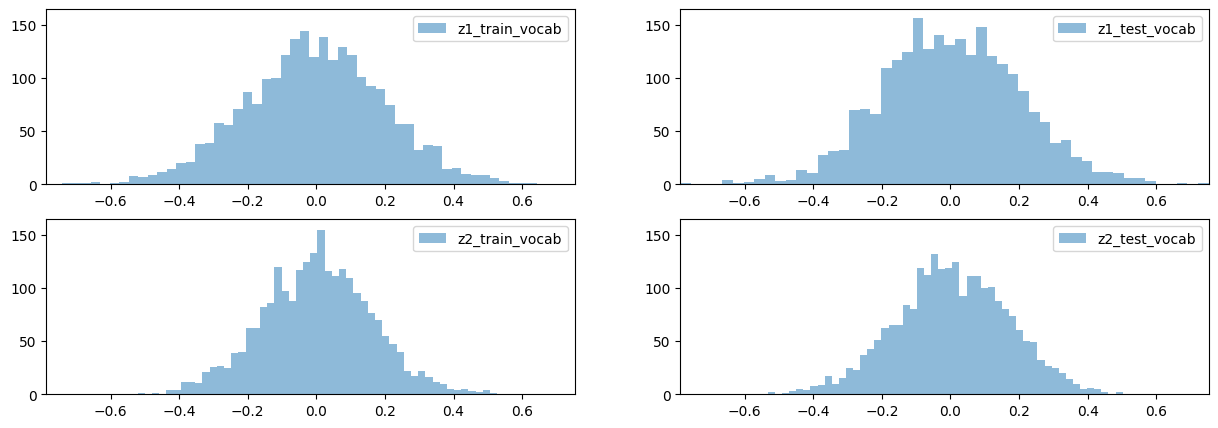

In [7]:
# Case 2: Better composition
z1_train_vocab = model[['cat', 'cat', 'cow', 'dog', 'dog', 'horse', 'horse', 'sheep']] + np.random.randn(8, 300) * 0.1
z2_train_vocab = model[['young', 'old', 'young', 'old', 'young', 'young', 'old', 'young']] + np.random.randn(8, 300) * 0.1

z1_test_vocab = model[np.repeat(['cow', 'sheep'], 4)] + np.random.randn(8, 300) * 0.1
z2_test_vocab = model[np.repeat(['old', 'old'], 4)] + np.random.randn(8, 300) * 0.1

cka_good_z1 = CKA(z1_train_vocab, z1_test_vocab)
print(f"CKA z1 (good composition): {cka_good_z1}")

cka_good_z2 = CKA(z2_train_vocab, z2_test_vocab)
print(f"CKA z2 (good composition): {cka_good_z2}")

z_train = np.concatenate([z1_train_vocab, z2_train_vocab], axis=0)
z_test = np.concatenate([z1_test_vocab, z2_test_vocab], axis=0)

cka_good = CKA(z_train, z_test)
print(f"CKA (good composition): {cka_good}")

fig, axis = plt.subplots(2, 2, figsize=(15, 5))
axis[0, 0].hist(z1_train_vocab.flatten(), bins=50, alpha=0.5, label='z1_train_vocab')
axis[0, 1].hist(z1_test_vocab.flatten(), bins=50, alpha=0.5, label='z1_test_vocab')
axis[1, 0].hist(z2_train_vocab.flatten(), bins=50, alpha=0.5, label='z2_train_vocab')
axis[1, 1].hist(z2_test_vocab.flatten(), bins=50, alpha=0.5, label='z2_test_vocab')
x_min = min(z1_train_vocab.min(), z1_test_vocab.min(), z2_train_vocab.min(), z2_test_vocab.min())
x_max = max(z1_train_vocab.max(), z1_test_vocab.max(), z2_train_vocab.max(), z2_test_vocab.max())
y_min = 0
y_max = max(axis[0, 0].get_ylim()[1], axis[0, 1].get_ylim()[1], axis[1, 0].get_ylim()[1], axis[1, 1].get_ylim()[1])
for ax in axis.flatten():
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend()
plt.show()

Ok this test does work. 
- We see for z1 an improvement (yet small) on the CKA (remmeber larger is better)
- We see for z2 the noise sample does better which is an interesting thing to look out for!
- we see overal good composition does better

Things to be careful of 
1. Clearly this is very curated 
2. Effectively the encoding process is unknown and what that does is also unknown 
3. this is a small amount of data - maybe very noise 
4. we have no idea what happens to latents that are not learning important stuff?? (And honestly my thoughts are it probably repeats itself - intuition from the individual latent pca analysis)


So whats the next step from here ...